In [ ]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [ ]:
import json
from bert_score import score

with open('/content/log.json', 'r') as f:
    data = json.load(f)

candidates = []
references = []
metadata = []

for item in data:
    candidates.append(item['generated_answer'])
    references.append(item['expected_answer'])
    metadata.append(item['question'])

P, R, F1 = score(candidates, references, lang='en', verbose=True)

for i, item in enumerate(data):
    item['bert_score_precision'] = round(P[i].item(), 4)
    item['bert_score_recall'] = round(R[i].item(), 4)
    item['bert_score_f1'] = round(F1[i].item(), 4)

with open('/content/log_with_bertscore.json', 'w') as f:
    json.dump(data, f, indent=2)

print("BERTScores inserted and saved to log_with_bertscore.json")

for i in range(len(candidates)):
    print(f"\nQ: {metadata[i]}")
    print(f"Expected: {references[i]}")
    print(f"Generated: {candidates[i]}")
    print(f"BERTScore -> Precision: {P[i]:.4f}, Recall: {R[i]:.4f}, F1: {F1[i]:.4f}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.13 seconds, 13.33 sentences/sec
BERTScores inserted and saved to log_with_bertscore.json

Q: Who is Winnie-the-Pooh?
Expected: Winnie-the-Pooh is a bear who lives in the forest under the name of Sanders and enjoys eating honey.
Generated: Christopher Robin
BERTScore -> Precision: 0.8059, Recall: 0.7743, F1: 0.7898

Q: Why did Pooh climb the tree?
Expected: Pooh climbed the tree because he heard buzzing and thought there were bees making honey, which he wanted to eat.
Generated: Pooh found the North Pole
BERTScore -> Precision: 0.9049, Recall: 0.8547, F1: 0.8791

Q: What happened when Pooh tried to get honey with a balloon?
Expected: Pooh tried to float to the honey using a blue balloon, pretending to be a little black rain cloud, but the bees got suspicious and he had to be brought down by Christopher Robin shooting the balloon.
Generated: jar
BERTScore -> Precision: 0.8202, Recall: 0.7742, F1: 0.7965

Q: Why did Pooh get stuck in Rabbit's doorway?
Expected: Pooh got stuck in

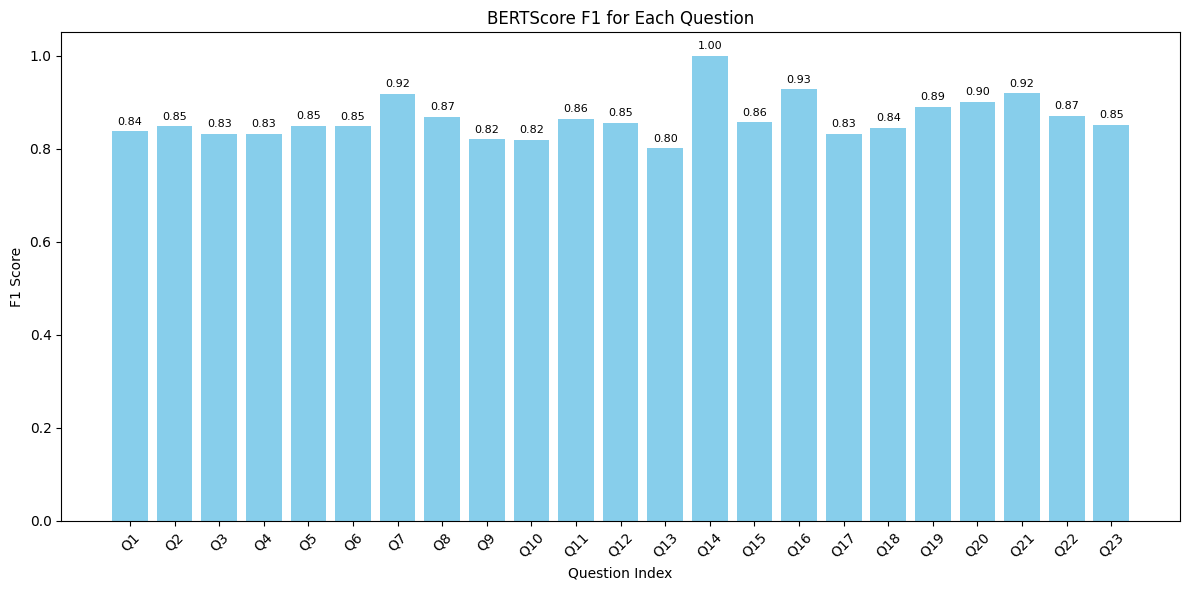

In [ ]:
import json
import matplotlib.pyplot as plt

with open('/content/log_with_bertscore.json', 'r') as f:
    data = json.load(f)

f1_scores = [item['bert_score_f1'] for item in data]
questions = [item['question'] for item in data]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(f1_scores)), f1_scores, color='skyblue')

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{f1_scores[i]:.2f}", ha='center', va='bottom', fontsize=8)

plt.title('BERTScore F1 for Each Question')
plt.xlabel('Question Index')
plt.ylabel('F1 Score')
plt.ylim(0, 1.05)
plt.xticks(range(len(questions)), [f"Q{i+1}" for i in range(len(questions))], rotation=45)
plt.tight_layout()

plt.savefig('/content/bert_f1_scores.png')
plt.show()

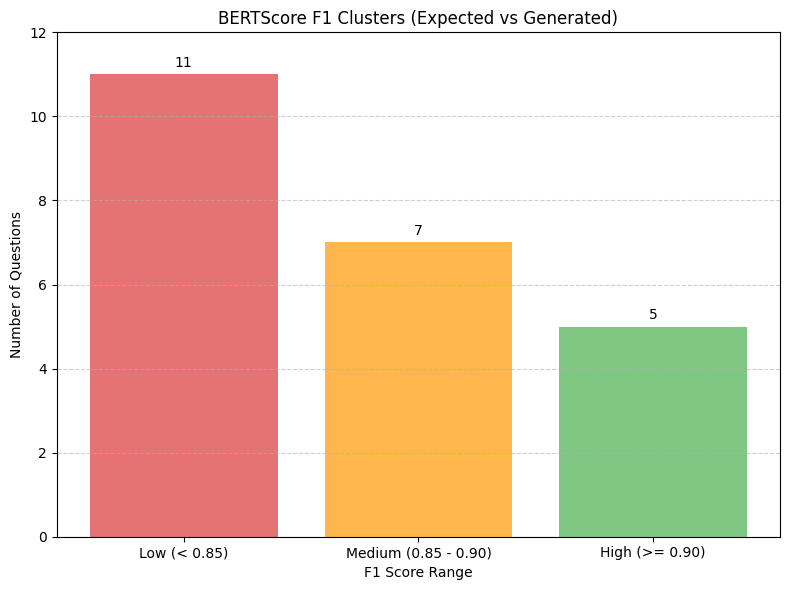

In [ ]:
import json
import matplotlib.pyplot as plt

with open('/content/log_with_bertscore.json', 'r') as f:
    data = json.load(f)

clusters = {
    'Low (< 0.85)': 0,
    'Medium (0.85 - 0.90)': 0,
    'High (>= 0.90)': 0
}

for item in data:
    f1 = item.get('bert_score_f1', 0)

    if f1 < 0.85:
        clusters['Low (< 0.85)'] += 1
    elif f1 < 0.90:
        clusters['Medium (0.85 - 0.90)'] += 1
    else:
        clusters['High (>= 0.90)'] += 1

plt.figure(figsize=(8, 6))
bars = plt.bar(clusters.keys(), clusters.values(), color=['#e57373', '#ffb74d', '#81c784'])
plt.title('BERTScore F1 Clusters (Expected vs Generated)')
plt.xlabel('F1 Score Range')
plt.ylabel('Number of Questions')
plt.ylim(0, max(clusters.values()) + 1)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
import json
from bert_score import score

with open('/content/log.json', 'r') as f:
    data = json.load(f)

retrieved_chunk_texts = []
expected_answers = []

for item in data:
    joined_chunks = " ".join(chunk["text"] for chunk in item.get("retrieved_chunks", []))
    retrieved_chunk_texts.append(joined_chunks)
    expected_answers.append(item["expected_answer"])

P, R, F1 = score(retrieved_chunk_texts, expected_answers, lang='en', verbose=True)

for i, item in enumerate(data):
    item['retrieved_chunks_bert_score_precision'] = round(P[i].item(), 4)
    item['retrieved_chunks_bert_score_recall'] = round(R[i].item(), 4)
    item['retrieved_chunks_bert_score_f1'] = round(F1[i].item(), 4)

with open('/content/log_with_chunk_bertscore.json', 'w') as f:
    json.dump(data, f, indent=2)

print("BERTScores from retrieved chunks vs. expected answer added to JSON.")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 2.86 seconds, 8.03 sentences/sec
✅ BERTScores from retrieved chunks vs. expected answer added to JSON.
